In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import torch
from torch import nn
from torch.optim import Adam
from torch.utils.data import DataLoader, TensorDataset

# data load and EDA

In [2]:
data = pd.read_csv("online_shoppers.csv")
data.head()

,SessionID,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,S-100000,0,0.0,0,NaN,1.0,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,S-100001,0,0.0,0,0.0,2.0,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,S-100002,0,0.0,0,NaN,1.0,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,S-100003,0,0.0,0,NaN,2.0,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,S-100004,0,0.0,0,NaN,10.0,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,NaN,True,False


In [3]:
columns = data.select_dtypes(include="number").columns

columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType'],
      dtype='str')

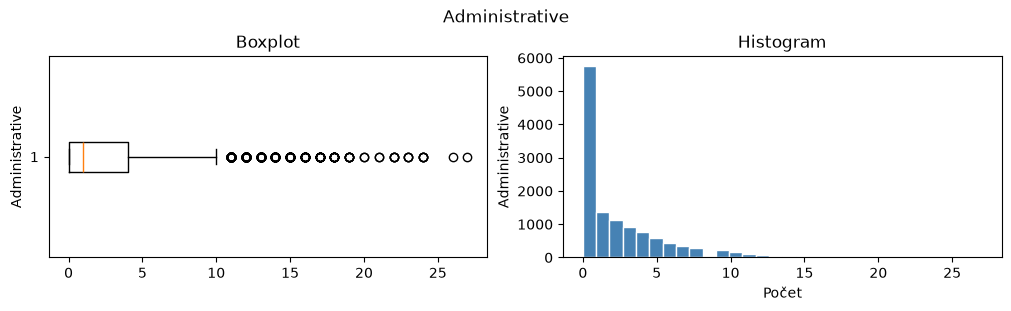

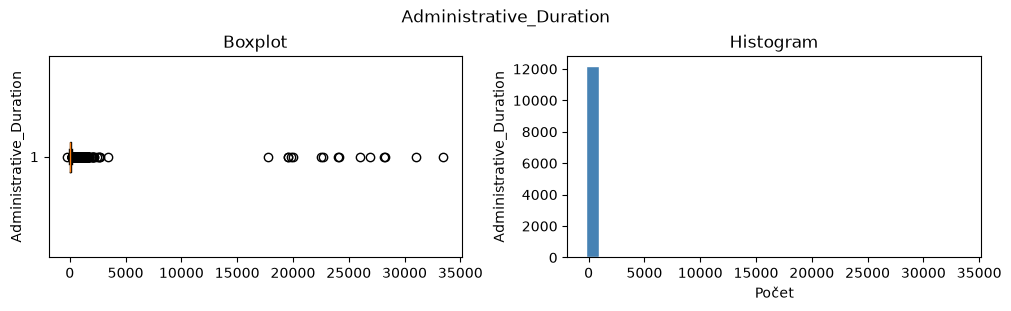

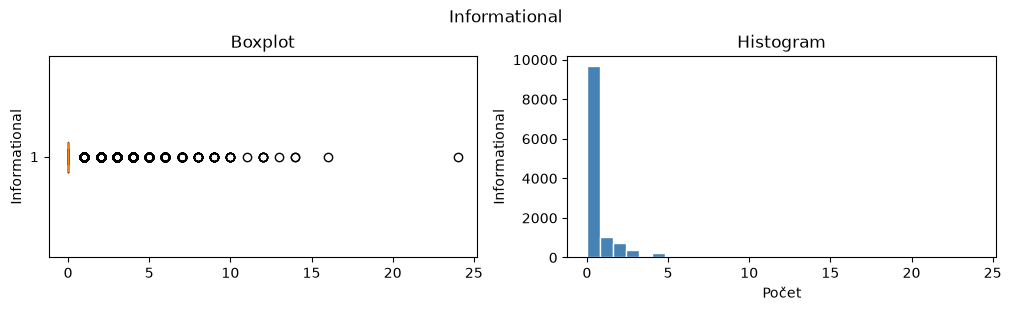

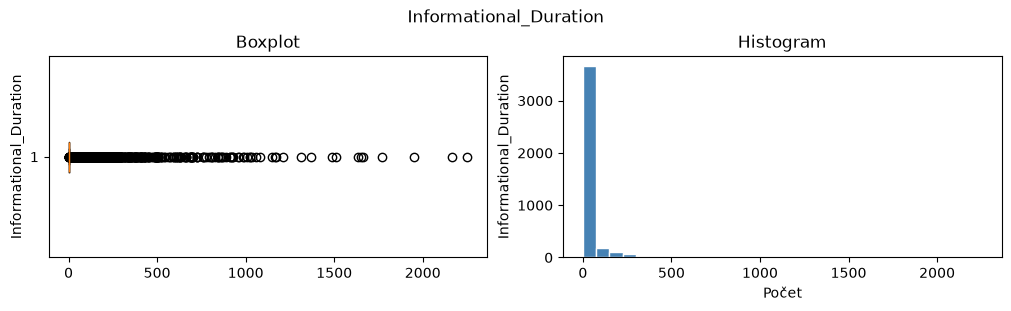

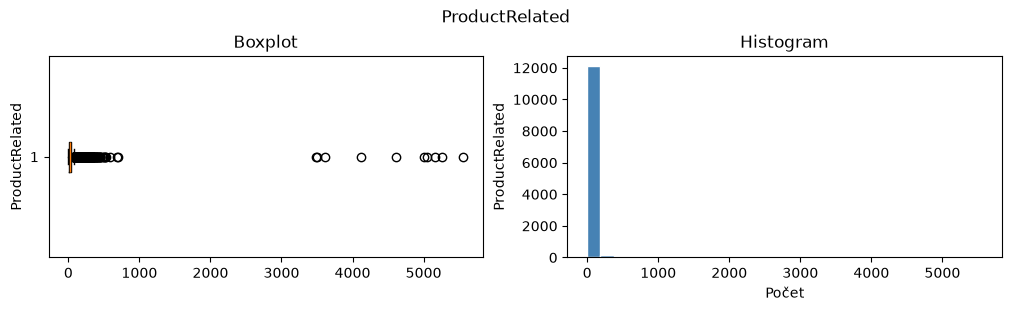

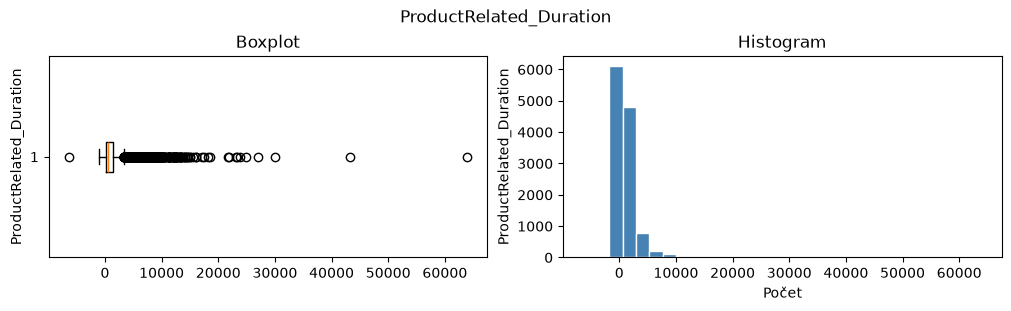

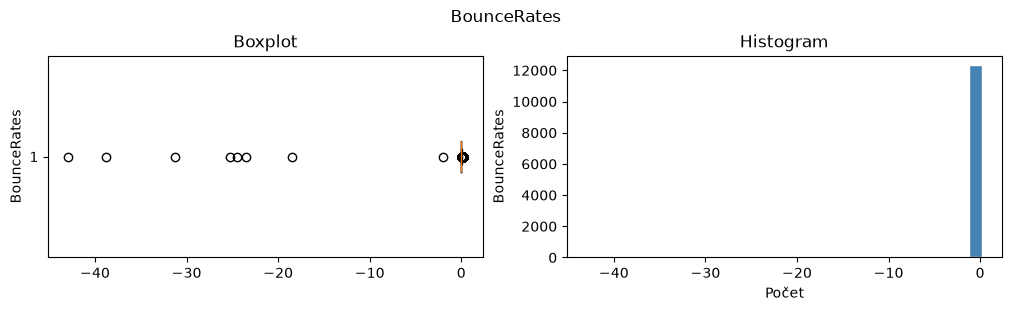

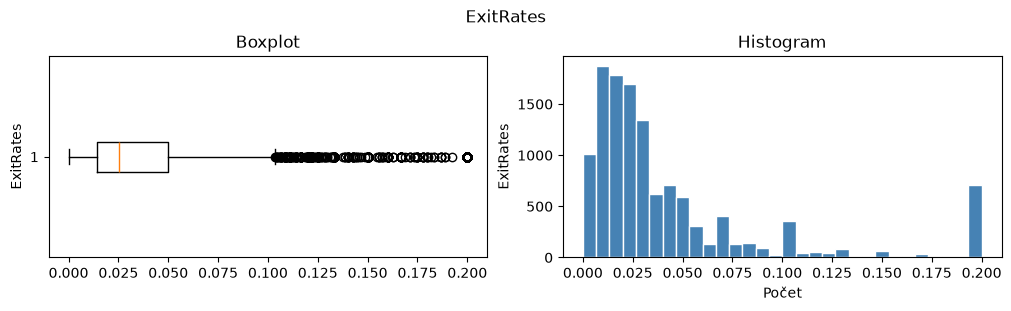

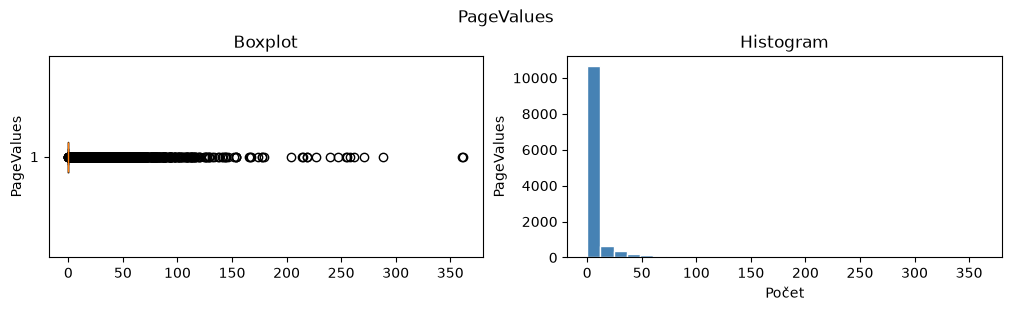

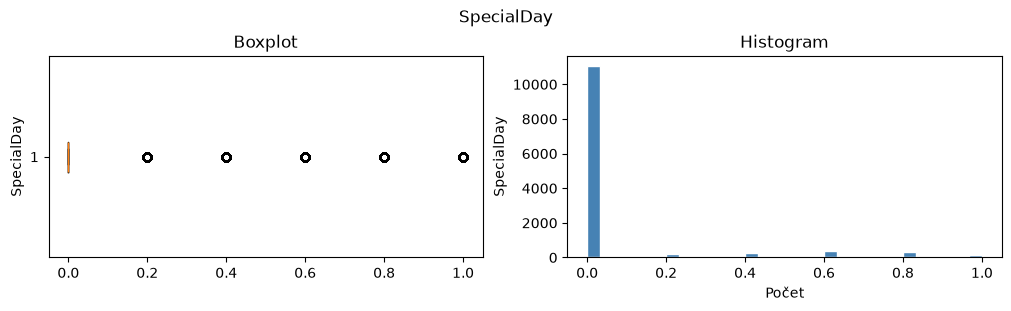

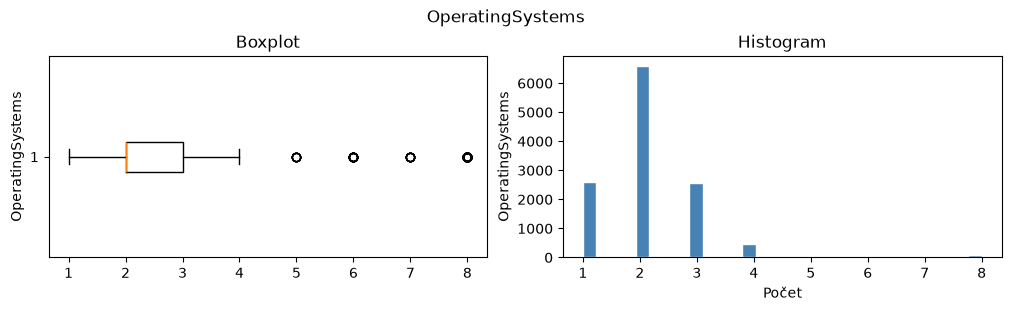

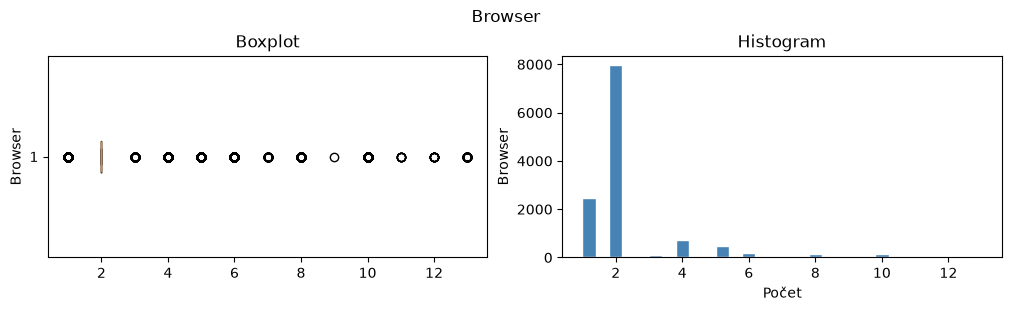

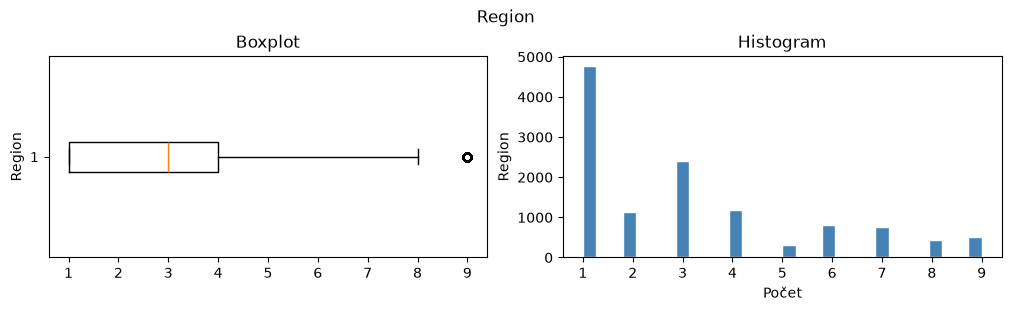

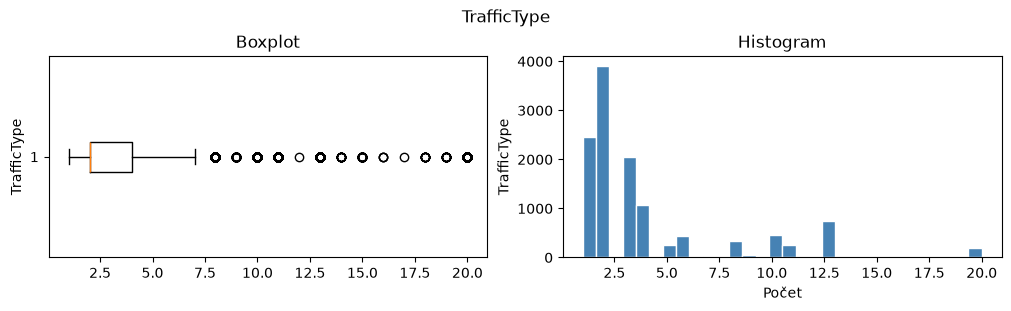

In [4]:
for column in columns:
    values = data[column].dropna()
    fig, axes = plt.subplots(1, 2, figsize=(10, 3), constrained_layout=True)
    axes[0].boxplot(values, orientation="horizontal")
    axes[0].set(title="Boxplot", ylabel=column)
    axes[1].hist(values, bins=30, color="steelblue", edgecolor="white")
    axes[1].set(title="Histogram", xlabel="Počet", ylabel=column)
    fig.suptitle(column)
    plt.show()

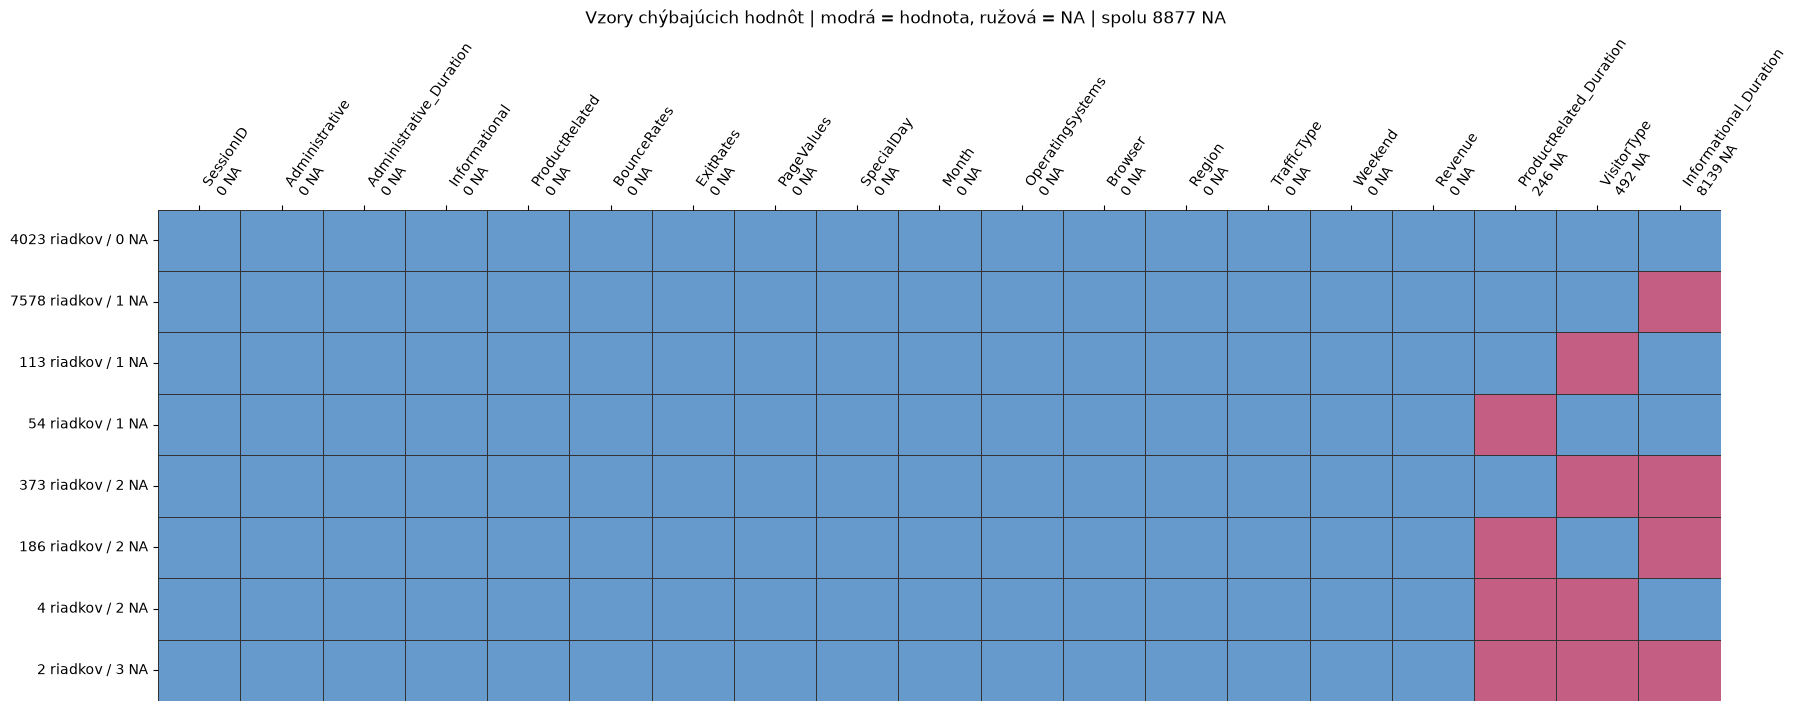

In [5]:
missing = data.isna()
ordered_cols = missing.sum().sort_values(kind="stable").index
patterns = missing.value_counts().rename("rows").reset_index()
patterns["na"] = patterns[data.columns].sum(axis=1)
patterns = patterns.sort_values(["na", "rows"], ascending=[True, False])

fig, ax = plt.subplots(figsize=(18, 7), constrained_layout=True)
sns.heatmap(patterns[ordered_cols].astype(int), cmap=["#6699cc", "#c45f83"],
            vmin=0, vmax=1, cbar=False, linewidths=0.5, linecolor="#333", ax=ax)
ax.set_xticklabels([f"{col}\n{missing[col].sum()} NA" for col in ordered_cols], rotation=55, ha="left")
ax.set_yticklabels([f"{rows} riadkov / {na} NA" for rows, na in zip(patterns["rows"], patterns["na"])], rotation=0)
ax.tick_params(axis="x", top=True, labeltop=True, bottom=False, labelbottom=False)
fig.suptitle(f"Vzory chýbajúcich hodnôt | modrá = hodnota, ružová = NA | spolu {missing.sum().sum()} NA")
plt.show()

- v cca 2/3 (8139/12334) dat chyba hodnota (NA) v poslednom stlpci Informational_Duration, co neni ani vhodne doplnat/nahradzat, preto tento stlpec je jednoduchsie a lepsie dropnut
- taktiez mozme dropnut indexy (rows) riadky, ktore su na grafe zobrazene ako posledne 2 kde chyba v 2 riadkoch 3 hodnoty a v 4 riadkoch 2 hodnoty

In [6]:
# dropnutie stlpca a riadkov
rows_to_drop = data["ProductRelated_Duration"].isna() | data["VisitorType"].isna()
data_clean = data.drop(index=data.index[rows_to_drop], columns="Informational_Duration").copy()

In [7]:
data_clean.describe()

,Administrative,Administrative_Duration,Informational,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,11601.000000,11601.000000,11601.000000,11601.000000,11601.000000,11601.000000,11601.000000,11601.000000,11601.000000,11601.000000,11601.000000,11601.000000,11601.000000
mean,2.326437,112.502691,0.507801,35.006637,1199.481299,0.004117,0.042697,6.154971,0.061546,2.122662,2.351608,3.140160,4.077752
std,3.327508,901.008974,1.270743,127.664326,1918.490414,0.748188,0.048397,19.006150,0.199062,0.910592,1.708669,2.394896,4.027833
min,0.000000,-214.548633,0.000000,0.000000,-6423.973010,-42.953427,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,7.000000,185.000000,0.000000,0.014251,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,8.000000,0.000000,18.000000,604.000000,0.003014,0.025000,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,94.600000,0.000000,38.000000,1467.654221,0.016667,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,33466.707646,24.000000,5258.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


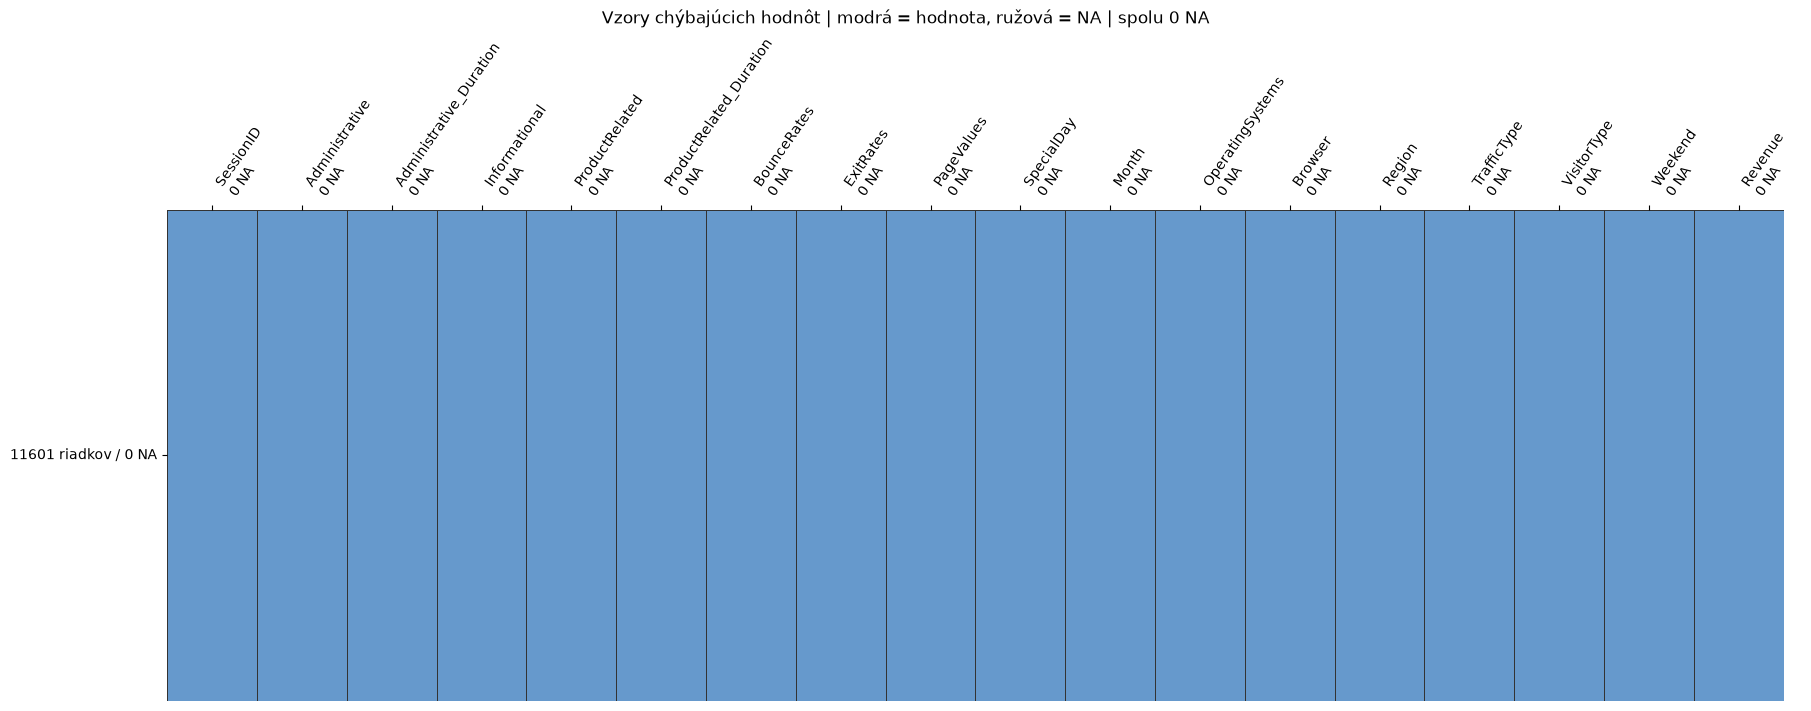

In [8]:
missing = data_clean.isna()
ordered_cols = missing.sum().sort_values(kind="stable").index
patterns = missing.value_counts().rename("rows").reset_index()
patterns["na"] = patterns[data_clean.columns].sum(axis=1)
patterns = patterns.sort_values(["na", "rows"], ascending=[True, False])

fig, ax = plt.subplots(figsize=(18, 7), constrained_layout=True)
sns.heatmap(patterns[ordered_cols].astype(int), cmap=["#6699cc", "#c45f83"],
            vmin=0, vmax=1, cbar=False, linewidths=0.5, linecolor="#333", ax=ax)
ax.set_xticklabels([f"{col}\n{missing[col].sum()} NA" for col in ordered_cols], rotation=55, ha="left")
ax.set_yticklabels([f"{rows} riadkov / {na} NA" for rows, na in zip(patterns["rows"], patterns["na"])], rotation=0)
ax.tick_params(axis="x", top=True, labeltop=True, bottom=False, labelbottom=False)
fig.suptitle(f"Vzory chýbajúcich hodnôt | modrá = hodnota, ružová = NA | spolu {missing.sum().sum()} NA")
plt.show()

## VisitorType vs ProductRelated a PageValues

In [9]:
visitor_types = ["Returning_Visitor", "New_Visitor", "Other"]
visitor_data = data_clean[data_clean["VisitorType"].isin(visitor_types)].copy()
for metric in ["PageValues", "ProductRelated"]:
    visitor_data[f"log1p_{metric}"] = np.log1p(visitor_data[metric])

visitor_data["VisitorType"].value_counts().reindex(visitor_types)

VisitorType
Returning_Visitor    9926
New_Visitor          1596
Other                  78
Name: count, dtype: int64

pouzity $\log{(1 + x)}$ (log1p), kvoli normalizacii velmi odlahlych hodnot a obsahovani 0 hodnot, logaritmus 1+x zachova 0 na 0, normalizacia zachovana aj kvoli porovnaniu roznych skupin

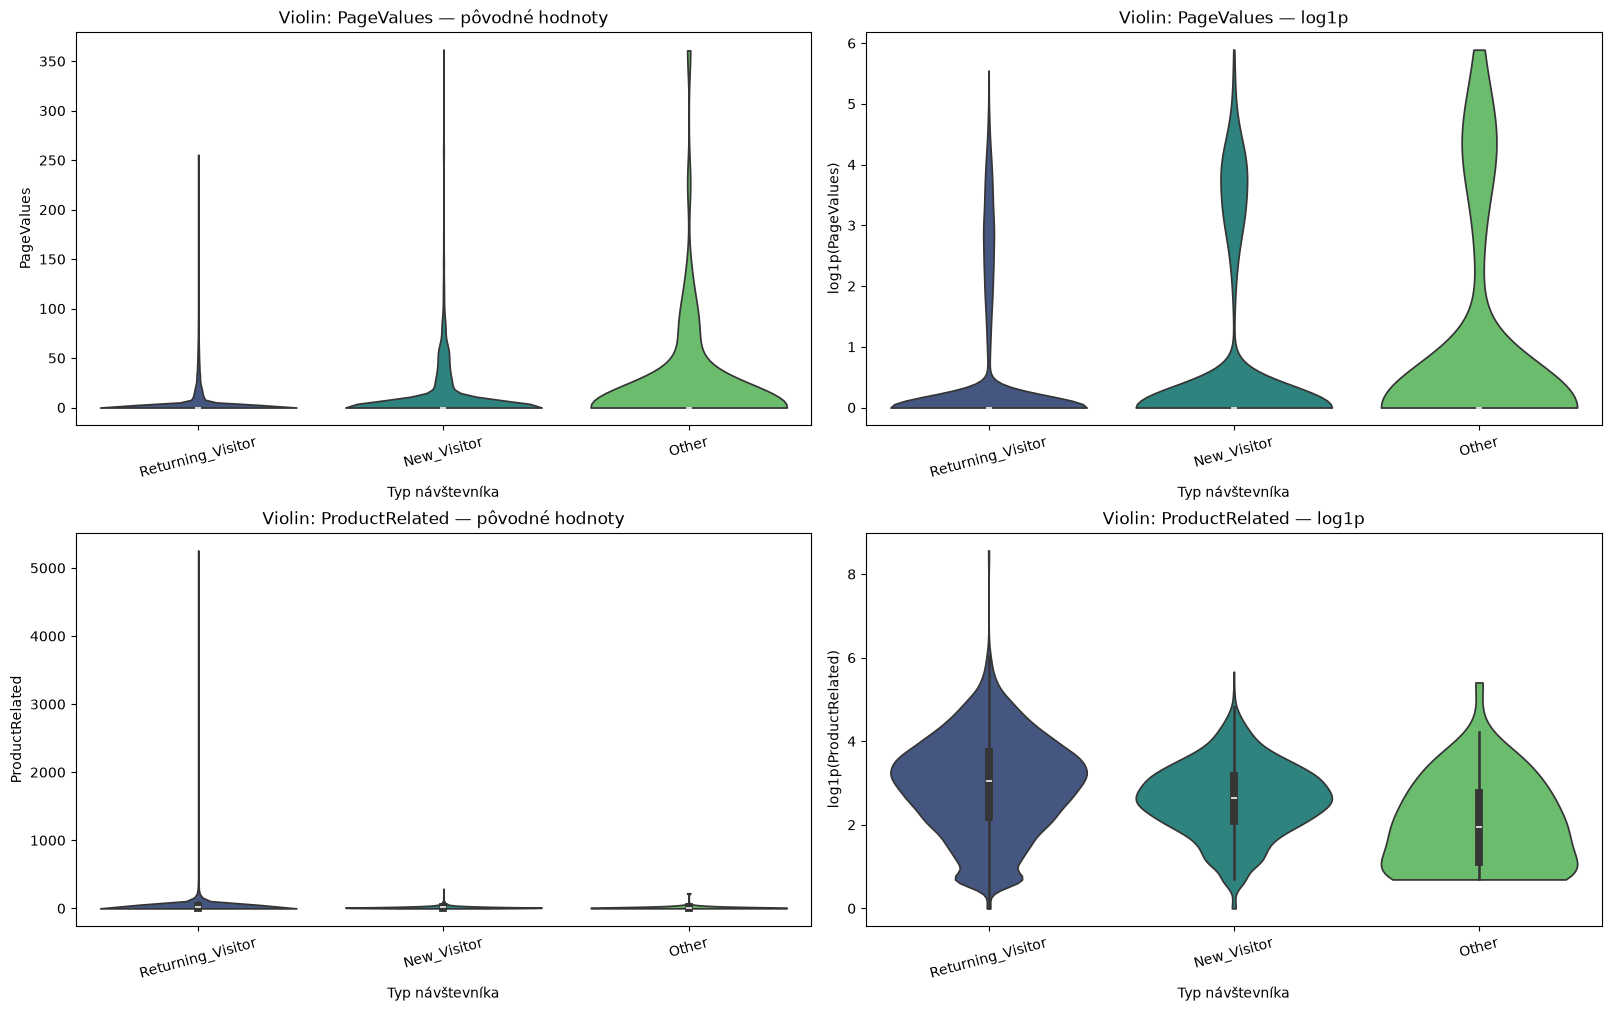

In [10]:
visitor_palette = dict(zip(visitor_types, sns.color_palette("viridis", len(visitor_types))))

fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)

for row, metric in enumerate(["PageValues", "ProductRelated"]):
    for col, variant in enumerate(["original", "log1p"]):
        value_column = metric if variant == "original" else f"log1p_{metric}"
        value_label = metric if variant == "original" else f"log1p({metric})"
        variant_label = "pôvodné hodnoty" if variant == "original" else "log1p"
        ax = axes[row, col]
        sns.violinplot(
            data=visitor_data, x="VisitorType", y=value_column,
            order=visitor_types, hue="VisitorType", hue_order=visitor_types,
            palette=visitor_palette, dodge=False, legend=False,
            inner="box", cut=0,
            ax=ax,
        )
        ax.set(title=f"Violin: {metric} — {variant_label}",
               xlabel="Typ návštevníka", ylabel=value_label)
        ax.tick_params(axis="x", rotation=15)

plt.show()


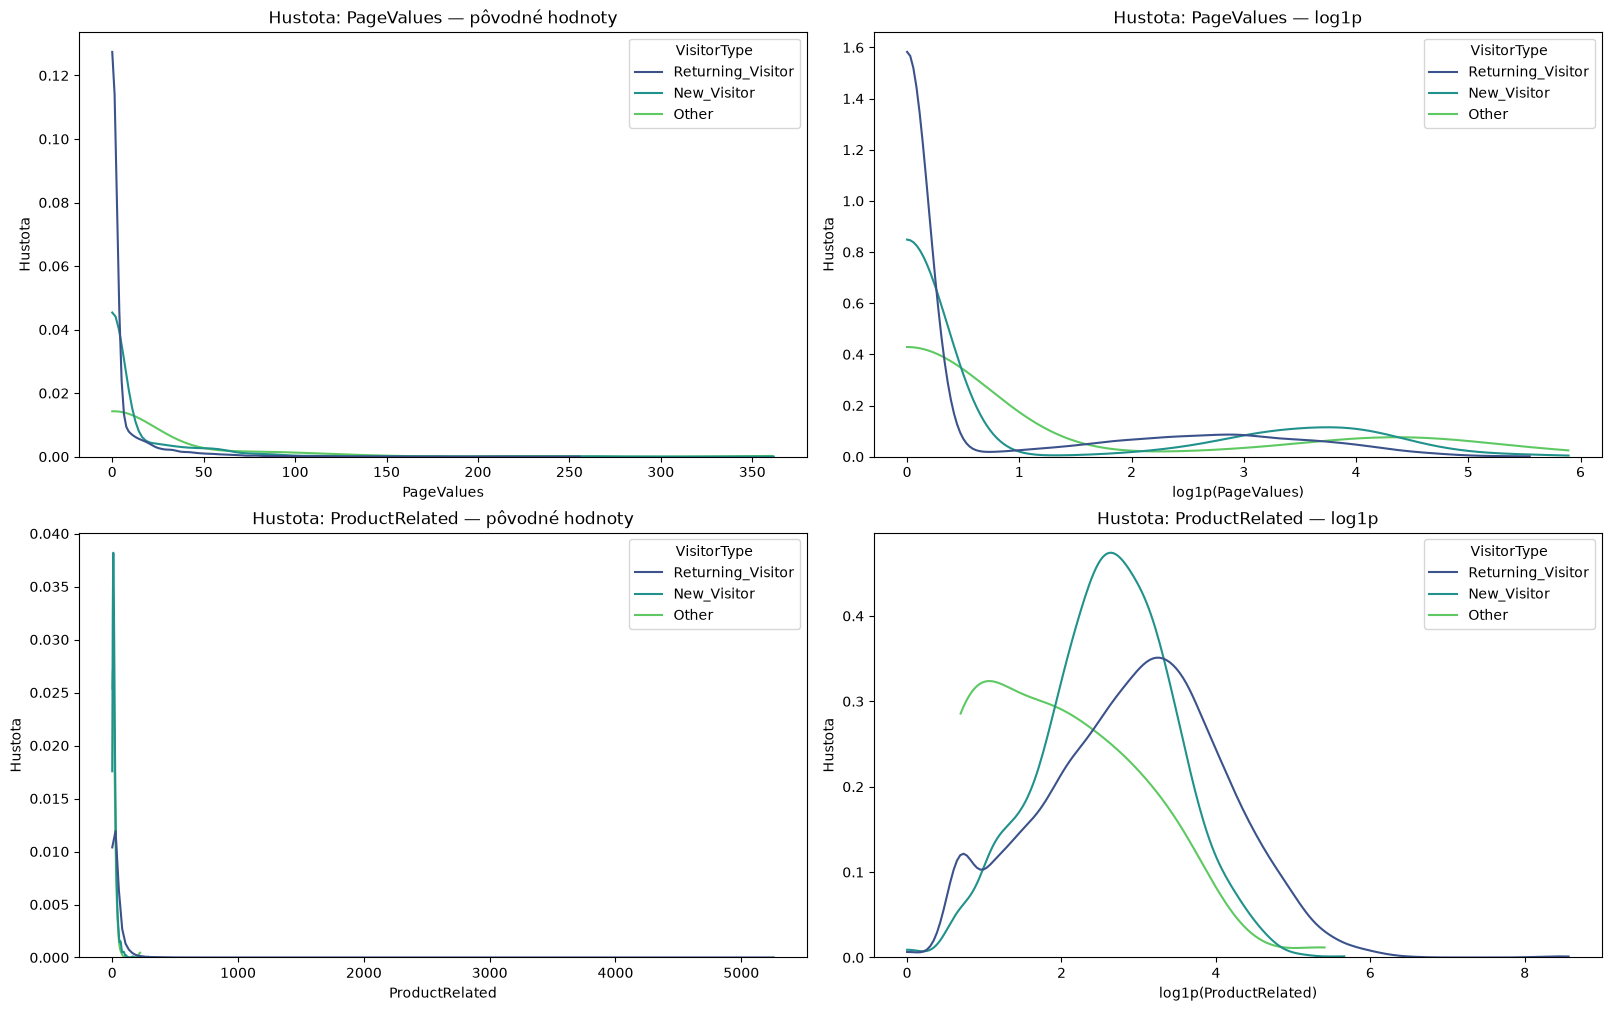

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)

for row, metric in enumerate(["PageValues", "ProductRelated"]):
    for col, variant in enumerate(["original", "log1p"]):
        value_column = metric if variant == "original" else f"log1p_{metric}"
        value_label = metric if variant == "original" else f"log1p({metric})"
        variant_label = "pôvodné hodnoty" if variant == "original" else "log1p"
        ax = axes[row, col]
        sns.kdeplot(
            data=visitor_data, x=value_column, hue="VisitorType",
            hue_order=visitor_types, palette=visitor_palette,
            common_norm=False,
            cut=0,
            ax=ax,
        )
        ax.set(title=f"Hustota: {metric} — {variant_label}",
               xlabel=value_label, ylabel="Hustota")

plt.show()


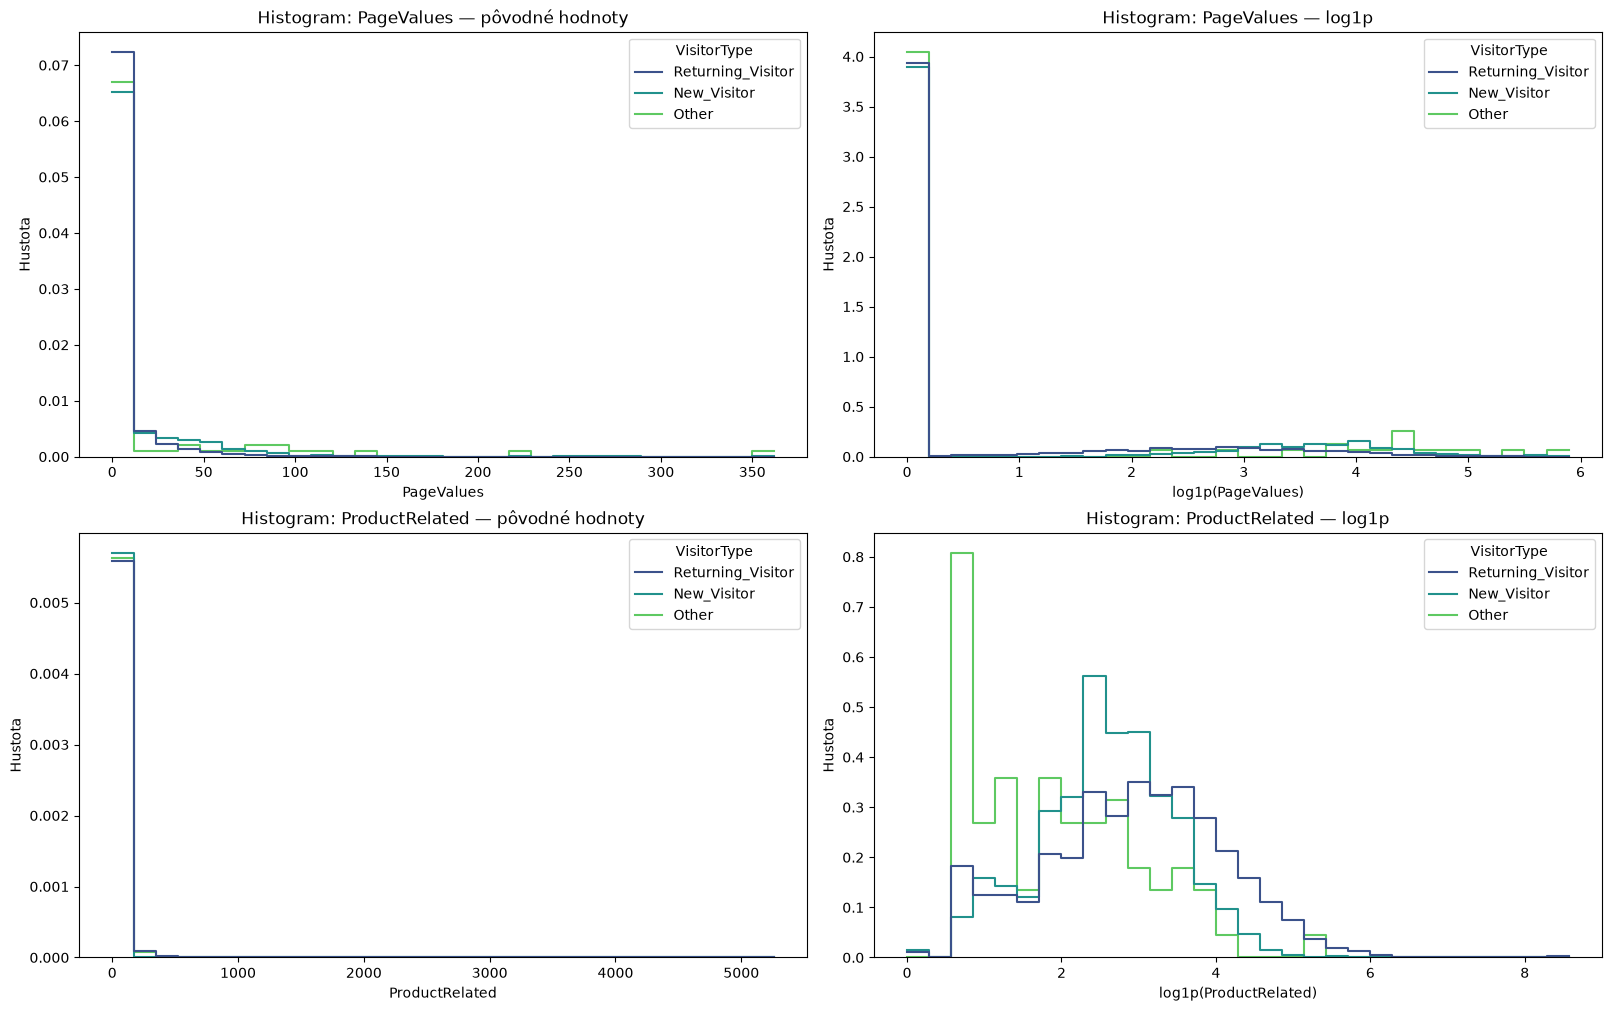

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)

for row, metric in enumerate(["PageValues", "ProductRelated"]):
    for col, variant in enumerate(["original", "log1p"]):
        value_column = metric if variant == "original" else f"log1p_{metric}"
        value_label = metric if variant == "original" else f"log1p({metric})"
        variant_label = "pôvodné hodnoty" if variant == "original" else "log1p"
        ax = axes[row, col]
        sns.histplot(
            data=visitor_data, x=value_column, hue="VisitorType",
            hue_order=visitor_types, palette=visitor_palette,
            common_norm=False,
            bins=30, stat="density", element="step", fill=False,
            ax=ax,
        )
        ax.set(title=f"Histogram: {metric} — {variant_label}",
               xlabel=value_label, ylabel="Hustota")

plt.show()


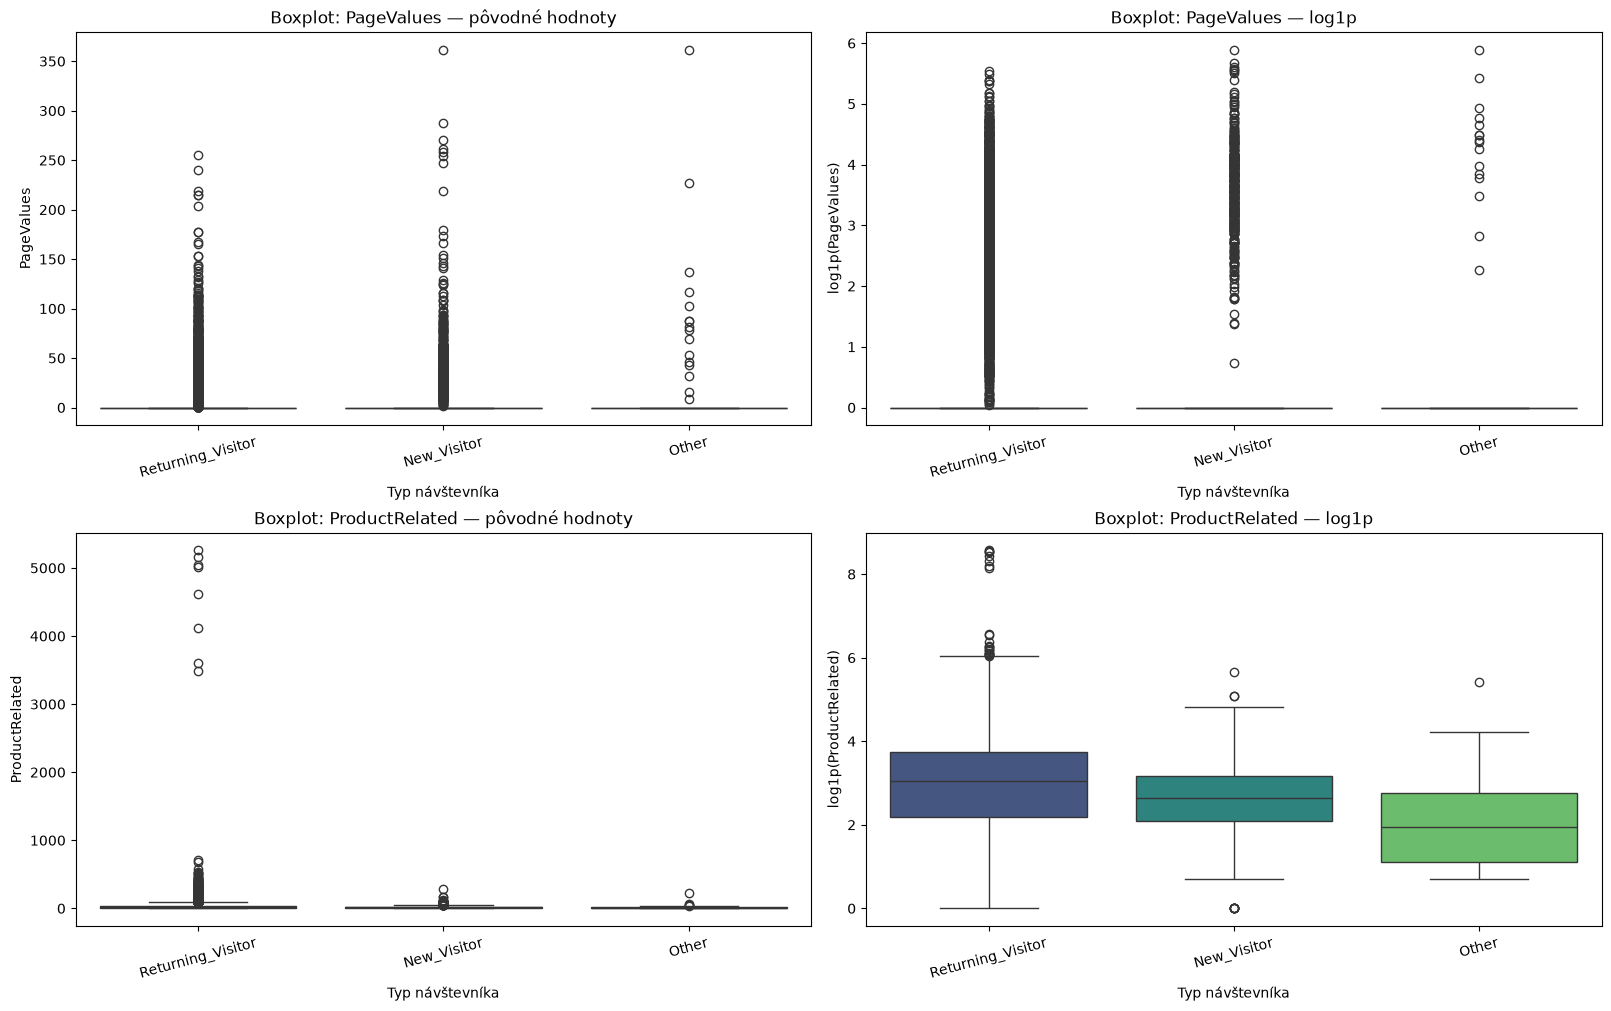

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)

for row, metric in enumerate(["PageValues", "ProductRelated"]):
    for col, variant in enumerate(["original", "log1p"]):
        value_column = metric if variant == "original" else f"log1p_{metric}"
        value_label = metric if variant == "original" else f"log1p({metric})"
        variant_label = "pôvodné hodnoty" if variant == "original" else "log1p"
        ax = axes[row, col]
        sns.boxplot(
            data=visitor_data, x="VisitorType", y=value_column,
            order=visitor_types, hue="VisitorType", hue_order=visitor_types,
            palette=visitor_palette, dodge=False, legend=False,
            ax=ax,
        )
        ax.set(title=f"Boxplot: {metric} — {variant_label}",
               xlabel="Typ návštevníka", ylabel=value_label)
        ax.tick_params(axis="x", rotation=15)

plt.show()


## Počet produktových stránok a čas na nich

Pearson r = 0.303; Spearman ρ = 0.882; n = 11601


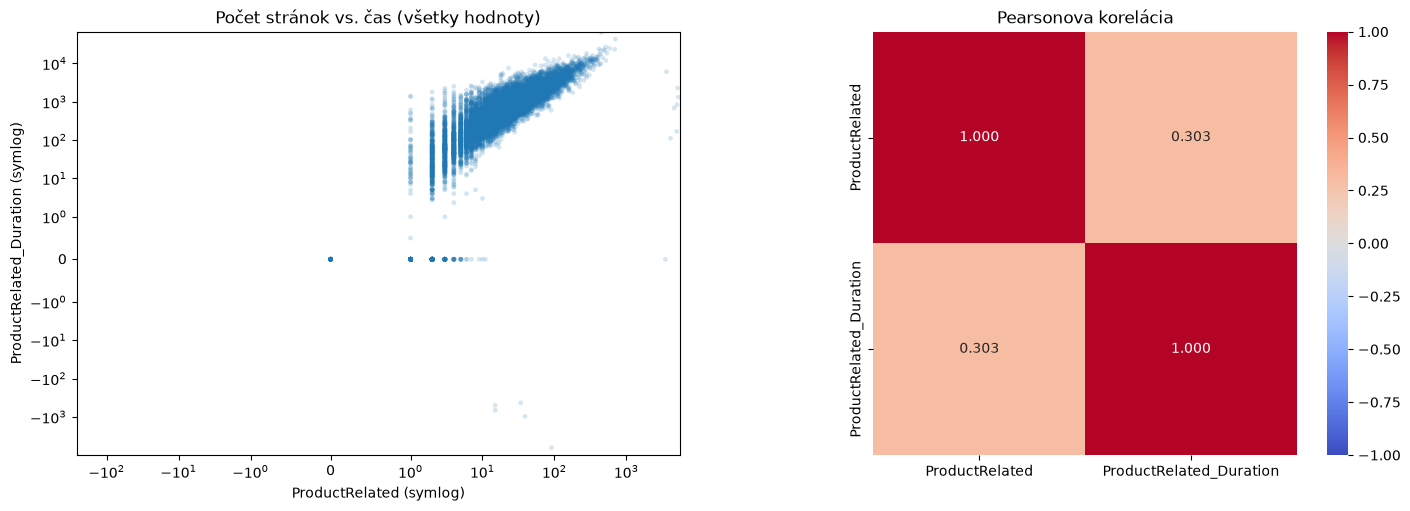

In [14]:
product_pair = data_clean[["ProductRelated", "ProductRelated_Duration"]].dropna()
pearson = product_pair.corr(method="pearson").iloc[0, 1]
spearman = product_pair.corr(method="spearman").iloc[0, 1]
print(f"Pearson r = {pearson:.3f}; Spearman ρ = {spearman:.3f}; n = {len(product_pair)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
sns.scatterplot(data=product_pair, x="ProductRelated", y="ProductRelated_Duration",
                alpha=0.18, s=12, edgecolor="none", ax=axes[0])
axes[0].set_xscale("symlog", linthresh=1)
axes[0].set_yscale("symlog", linthresh=1)
axes[0].set(title="Počet stránok vs. čas (všetky hodnoty)",
            xlabel="ProductRelated (symlog)", ylabel="ProductRelated_Duration (symlog)")
sns.heatmap(product_pair.corr(method="pearson"), annot=True, fmt=".3f",
            cmap="coolwarm", vmin=-1, vmax=1, square=True, ax=axes[1])
axes[1].set_title("Pearsonova korelácia")
plt.show()

In [15]:
X = data_clean.drop(columns=["SessionID", "Revenue"])
y = data_clean["Revenue"].copy()
print(f"X: {X.shape}, y: {y.shape}")

X: (11601, 16), y: (11601,)
